In [4]:
# librerias
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy,purity
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver, Signal
from qiskit_dynamics.backend import parse_backend_hamiltonian_dict

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")



import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities(statevector):
    probabilities = statevector.probabilities()
    num_qubits = int(np.log2(len(probabilities)))
    basis_states = [f"|{i:0{num_qubits}b}⟩" for i in range(2**num_qubits)]
    
    plt.figure(figsize=(10, 5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel('Computational basis states', fontsize=16)
    plt.ylabel('Probability', fontsize=16)
    # plt.title('Measurement Probabilities of Statevector')
    plt.ylim(0, 1.0)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()


In [5]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities_qudit(statevector, d=2):
    """
    Grafica probabilidades de un statevector de qudits.
    Usa etiquetas en base d (por defecto qubits: d=2).
    """
    probabilities = statevector.probabilities()
    dim = len(probabilities)
    
    # Número de qudits
    num_qudits = int(round(np.log(dim) / np.log(d)))
    
    # Etiquetas en base d (por ejemplo base=3 para qutrits)
    basis_states = []
    for i in range(dim):
        digits = np.base_repr(i, base=d).zfill(num_qudits)
        basis_states.append(f"|{digits}⟩")
    
    # Gráfico
    plt.figure(figsize=(12,5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel(f'Computational basis states (d={d})',fontsize=20)
    plt.ylabel('Probability',fontsize=20)
    plt.title(f'Measurement Probabilities of {num_qudits} qudits (d={d})',fontsize=20)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [6]:
# Llamar fake backend
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)
print(v7, v8, v9)

4.755587722216812 4.812531480182586 4.637614165110824


In [7]:
# Definir los operadores 
dim = 2
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 = np.kron(ident,np.kron(ident, N))
N1 = np.kron(ident,np.kron(N, ident))
N2 = np.kron(np.kron(N, ident),ident)

a0 = np.kron(ident,np.kron(ident, a))
a1 = np.kron(ident,np.kron(a, ident))
a2 = np.kron(np.kron(a, ident),ident)


a0dag = np.kron(ident,np.kron(ident, adag))
a1dag = np.kron(ident,np.kron(adag, ident))
a2dag = np.kron(np.kron(adag, ident),ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  +2*np.pi*v8 * N1  + 2*np.pi*v9* N2   + J78*(a0dag @ a1 +  a0 @ a1dag) + J89*(a1dag @ a2 +  a1 @ a2dag)

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)
H_drive9 =  r2 * (a2 + a2dag)
  

y0  = Statevector.from_label("000")

In [8]:

propiedades.qubit_property(3,name='frequency')

(4747181100.193296,
 datetime.datetime(2025, 2, 26, 14, 43, 10, tzinfo=tzoffset(None, -18000)))

In [9]:
solver = Solver(
    static_hamiltonian=static_ham,
    hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
    hamiltonian_channels=["d0", "d1", "d2", "u0", "u1"],
    channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
    dt=dt,
    array_library="jax",
)

In [10]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1, t_2, t_3,A0, A1, A2, A3, A4  = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
    t_2 = int(t_2)
    t_3 = int(t_3)
    
    with pulse.build(name="GHZ Pulse") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        d2 = pulse.DriveChannel(2)
        u0 = pulse.ControlChannel(0)
        u1 = pulse.ControlChannel(1)

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
           
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)
        
      #  # delay pulso d2 y u1 
        pulse.delay(duration= (t_0 + t_1 + 1 ), channel= d2)
        pulse.delay(duration= (t_0+ t_1 + t_2 + 2  ), channel= u1)
        
        
      #   # pulsos locales d1 y d2 
        pulse.play(pulse.Constant(duration=t_2, amp=A3),d2)
      #   # pulse.play(pulse.Constant(duration=t_2, amp=A4),d1)
        
      #  # pulso local d2
        # pulse.play(pulse.Constant(duration=t_3, amp=A4),d2)
           
      # # pulso u1
        pulse.play(pulse.Constant(duration=t_3, amp=A4),u1)
        
    return kp


In [11]:
def objective_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf

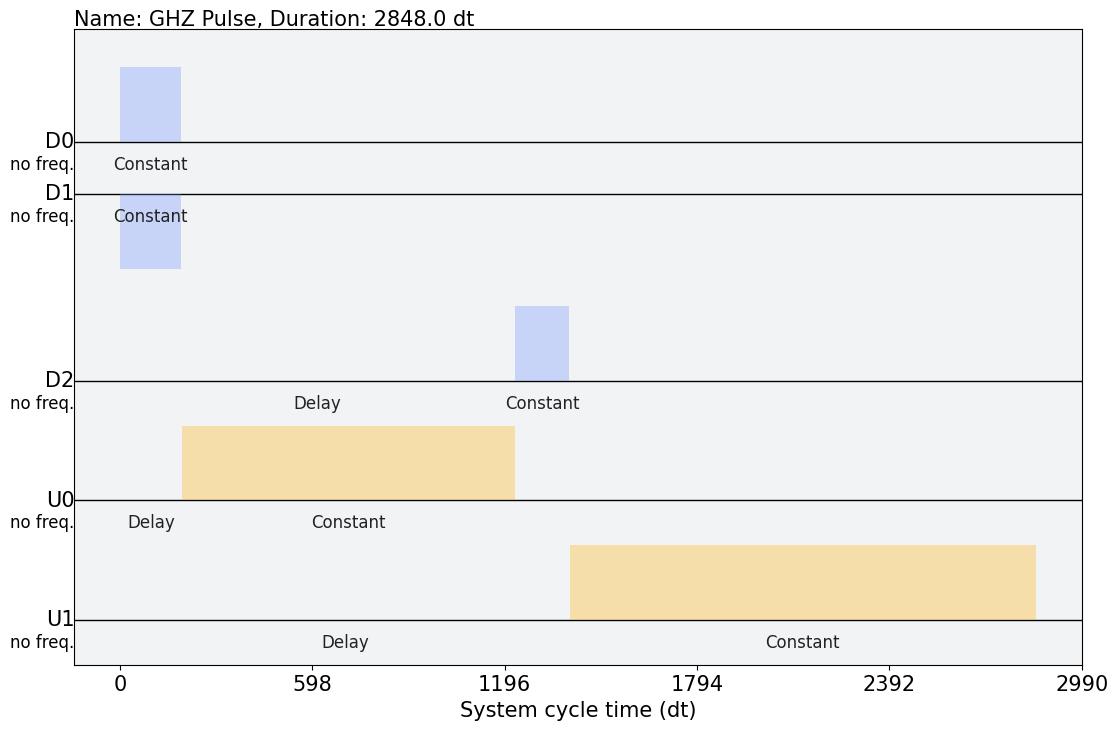

In [12]:
parametros_optimos =  [
        202.9295423047658,
        1258.1648854894204,
        192.1238241246524,
        1860.2496455494108,
        0.4302391752867789,
        -0.05416696911702623,
        0.45105849258854414,
        0.5052878150042629,
        -0.48319328703627806,
       ]

x =  [ 2.02977227e+02,  1.24590825e+03,  1.92893062e+02,  1.85898891e+03,
  4.30640491e-01, -5.69626179e-02,  4.51052541e-01,  5.10797206e-01,
 -4.79180337e-01]



x0 =[ 2.02009625e+02,  1.27298658e+03,  1.75001941e+02,  1.81997862e+03,
  4.29963073e-01, -7.70238654e-02,  4.52135477e-01,  3.83286156e-01,
 -4.91208525e-01]


x1 =  [ 1.90153970e+02,  1.06419199e+03,  1.59748288e+02,  1.47613390e+03,
  4.87011015e-01, -6.46923991e-01,  6.63427649e-01,  1.64118785e-01,
  6.30356450e-01]

x2 = [ 1.91779586e+02,  1.03750354e+03,  1.68736170e+02,  1.45046248e+03,
  4.90394435e-01, -6.91612520e-01,  6.65492967e-01,  1.65200193e-01,
  6.19735822e-01]

X_GHZ =  [
    1.91779586e+02, 1.03750354e+03, 1.68736170e+02, 1.45046248e+03,
    4.90394435e-01, -6.91612520e-01, 6.65492967e-01, 1.65200193e-01,
    6.19735822e-01
]

esque_pul(X_GHZ).draw()

In [13]:
objective_12(X_GHZ).draw("latex_source")

'(-0.325087979 + 0.5835832978 i) |000\\rangle+(-0.1429269432 - 0.0194928303 i) |001\\rangle+(0.0210944001 - 0.1113714689 i) |010\\rangle+(-0.0104351663 - 0.1369005982 i) |011\\rangle+(0.1206952367 + 0.0296263868 i) |100\\rangle+(0.1283407639 - 0.0084041756 i) |101\\rangle+(0.0318967537 + 0.1532438365 i) |110\\rangle+(0.4245584034 - 0.5142986054 i) |111\\rangle'

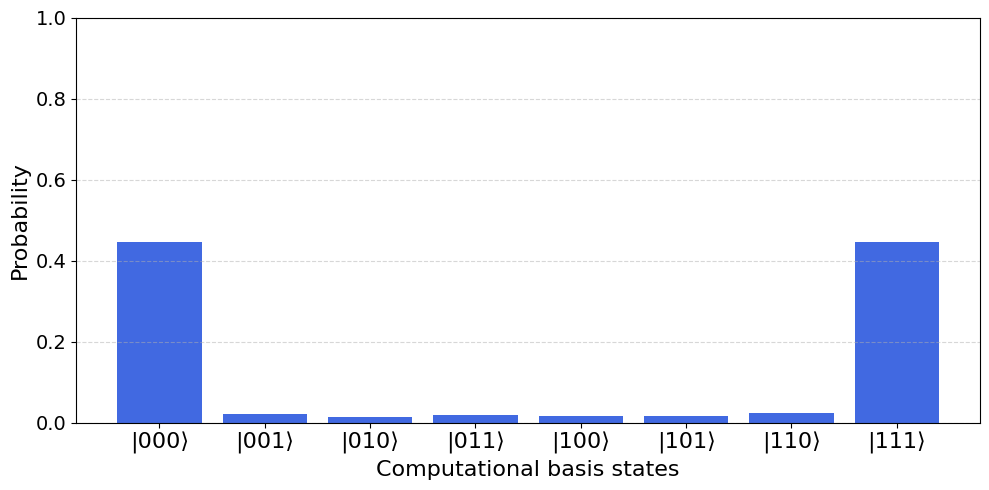

In [14]:
plot_statevector_probabilities(objective_12(X_GHZ))

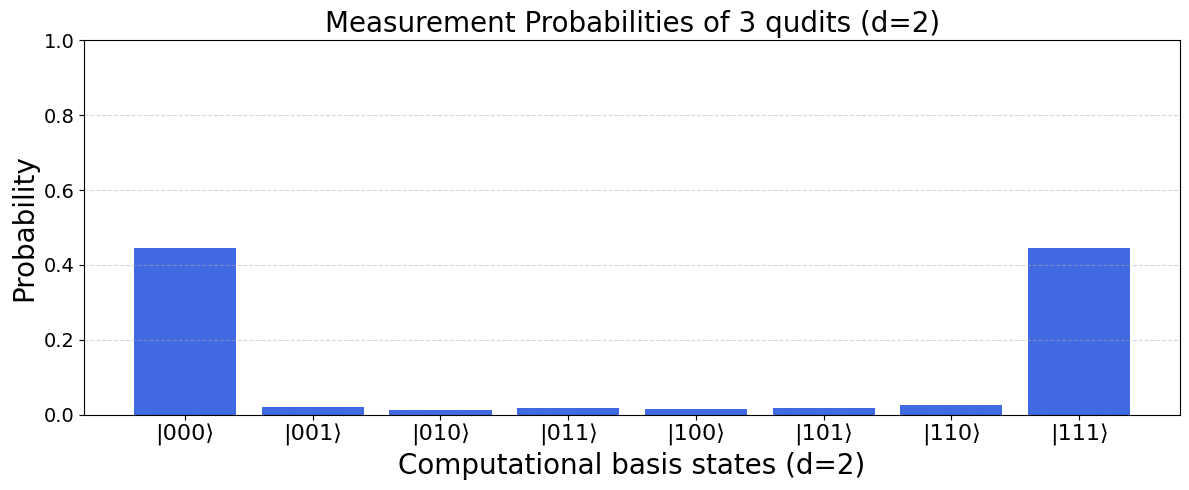

In [15]:
plot_statevector_probabilities_qudit(objective_12(X_GHZ), d=2)

In [16]:

def three_t(yf):
    m1 = (yf[0] * yf[7])**2 + (yf[1] * yf[6])**2 + (yf[2] * yf[5])**2 + (yf[3] * yf[4])**2
    m2 = (yf[0] * yf[7] * yf[3] * yf[4] + yf[0] * yf[7] * yf[5] * yf[2] +
          yf[0] * yf[7] * yf[6] * yf[1] + yf[3] * yf[4] * yf[5] * yf[2] +
          yf[3] * yf[4] * yf[6] * yf[1] + yf[5] * yf[2] * yf[6] * yf[1])
    m3 = yf[0] * yf[6] * yf[5] * yf[3] + yf[7] * yf[1] * yf[2] * yf[4]
    tau =  4 * abs(m1 - 2 * m2 + 4 * m3)
    return tau

def three_tangle(psi):
    """
    Calcula el three-tangle τ_ABC para un estado puro de tres qubits.

    Parámetro:
        psi: Statevector de 3 qubits (dim=8)

    Retorna:
        tau_ABC: float
    """
    rho_A = partial_trace(psi, [1, 2])   # traza sobre B y C
    C_A_BC = np.sqrt(2 * (1 - np.trace(rho_A.data @ rho_A.data).real))

    # Concurrencia entre pares, calculada con concurrencia de Qiskit
    rho_AB = partial_trace(psi, [2])  # traza sobre qubit C
    C_AB = concurrence(rho_AB)

    rho_AC = partial_trace(psi, [1])  # traza sobre qubit B
    C_AC = concurrence(rho_AC)

    tau_ABC = C_A_BC**2 - C_AB**2 - C_AC**2
    return np.clip(tau_ABC, 0, 1)

In [17]:
three_tangle(objective_12(X_GHZ))

np.float64(0.9994767248130607)

In [18]:
three_t(objective_12(X_GHZ))

np.float64(0.9994767247185403)

In [19]:
negativity(objective_12(X_GHZ),[0])

np.float64(0.49999874071408423)

In [20]:
negativity(objective_12(X_GHZ),[2])

np.float64(0.4998719277262649)

In [21]:
negativity(objective_12(X_GHZ),[1])

np.float64(0.4999961990286653)

In [23]:
import gc
gc.collect()

0

In [24]:
def objective_123(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    
    t = sol.y[-1]/np.linalg.norm(sol.y[-1])
    
    tabc = three_t(t)



    
    return -tabc 

In [25]:
objective_123(x2)

np.float64(-0.9994767247185403)

In [111]:
# Callback para imprimir en cada iteración
def callback(xk):
    costo = objective_123(xk)
    print(f" Cost: {costo:.6f} | x: {xk}")

x0 =[ 1.90153970e+02,  1.06419199e+03,  1.59748288e+02,  1.47613390e+03,
  4.87011015e-01, -6.46923991e-01,  6.63427649e-01,  1.64118785e-01,
  6.30356450e-01]


bounds = [(180,250),
          (790,2000),
          (150,300),
          (790,2000),
          (-0.9,0.9),
          (-0.9,0.92772),
          (-0.9726,0.962552),
          (-0.9,0.92322),
          (-0.9,0.92322),
          ]


result = minimize(fun= objective_123
                  ,x0=x0 ,args=(),
                  method= 'Nelder-Mead',
                  callback= callback,
    options={'disp': True},
    bounds=bounds)

 Cost: -0.986496 | x: [ 1.90153970e+02  1.06419199e+03  1.67735702e+02  1.47613390e+03
  4.87011015e-01 -6.46923991e-01  6.63427649e-01  1.64118785e-01
  6.30356450e-01]
 Cost: -0.986496 | x: [ 1.90153970e+02  1.06419199e+03  1.67735702e+02  1.47613390e+03
  4.87011015e-01 -6.46923991e-01  6.63427649e-01  1.64118785e-01
  6.30356450e-01]
 Cost: -0.986496 | x: [ 1.90153970e+02  1.06419199e+03  1.67735702e+02  1.47613390e+03
  4.87011015e-01 -6.46923991e-01  6.63427649e-01  1.64118785e-01
  6.30356450e-01]
 Cost: -0.986496 | x: [ 1.90153970e+02  1.06419199e+03  1.67735702e+02  1.47613390e+03
  4.87011015e-01 -6.46923991e-01  6.63427649e-01  1.64118785e-01
  6.30356450e-01]
 Cost: -0.986496 | x: [ 1.90153970e+02  1.06419199e+03  1.67735702e+02  1.47613390e+03
  4.87011015e-01 -6.46923991e-01  6.63427649e-01  1.64118785e-01
  6.30356450e-01]
 Cost: -0.986496 | x: [ 1.90153970e+02  1.06419199e+03  1.67735702e+02  1.47613390e+03
  4.87011015e-01 -6.46923991e-01  6.63427649e-01  1.64118785e-0

## Matrices para GHZ

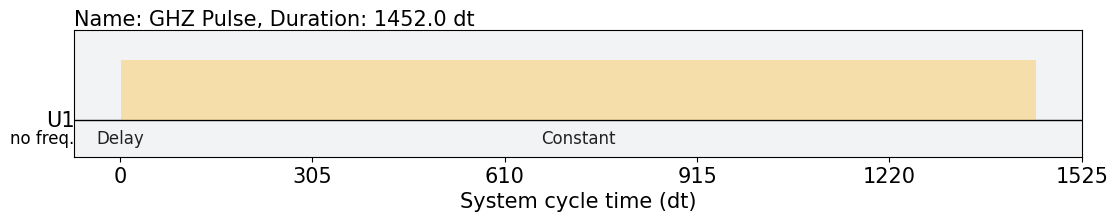

In [23]:
x0 = [ 1.91779586e+02,  1.03750354e+03,  1.68736170e+02,  1.45046248e+03,
  4.90394435e-01, -6.91612520e-01,  6.65492967e-01,  1.65200193e-01,
  6.19735822e-01]


y00 =   [ 1.91779586e+02, 0,  0,  0,
  4.90394435e-01, 0, 0, 0,  0]


x00 =   [ 1.91779586e+02,  0.0,  0.0, 0.0,
          0.0, -6.91612520e-01,  0.0, 0.0, 0.0]



x01 = [0,  1.03750354e+03,  0, 0,
0, 0,  6.65492967e-01,  0.0,  0.0]


x02 =[ 0.0,  0.0,  1.68736170e+02, 0.0,
  0.0, 0.0,  0.0,  1.65200193e-01,  0.0]


x03 =   [ 0.0, 0.0,  0.0,  1.45046248e+03,
  0.0, 0.0,  0.0,  0.0, 6.19735822e-01]

esque_pul(x03).draw()

In [24]:
y0 = Statevector.from_label("000")
y1 = Statevector.from_label("001")
y2 = Statevector.from_label("010")
y3 = Statevector.from_label("011")
y4 = Statevector.from_label("100")
y5 = Statevector.from_label("101")
y6 = Statevector.from_label("110")
y7 = Statevector.from_label("111")

pulso_t = x03

initial_list = [y0, y1, y2, y3, y4, y5, y6, y7]

In [25]:
def objective_evolu(x,i):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=initial_list[i],
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])

    return yf

In [26]:
y0n = objective_evolu(pulso_t,0)
y1n = objective_evolu(pulso_t,1)
y2n = objective_evolu(pulso_t,2)
y3n = objective_evolu(pulso_t,3)
y4n = objective_evolu(pulso_t,4)
y5n = objective_evolu(pulso_t,5)
y6n = objective_evolu(pulso_t,6)
y7n = objective_evolu(pulso_t,7)

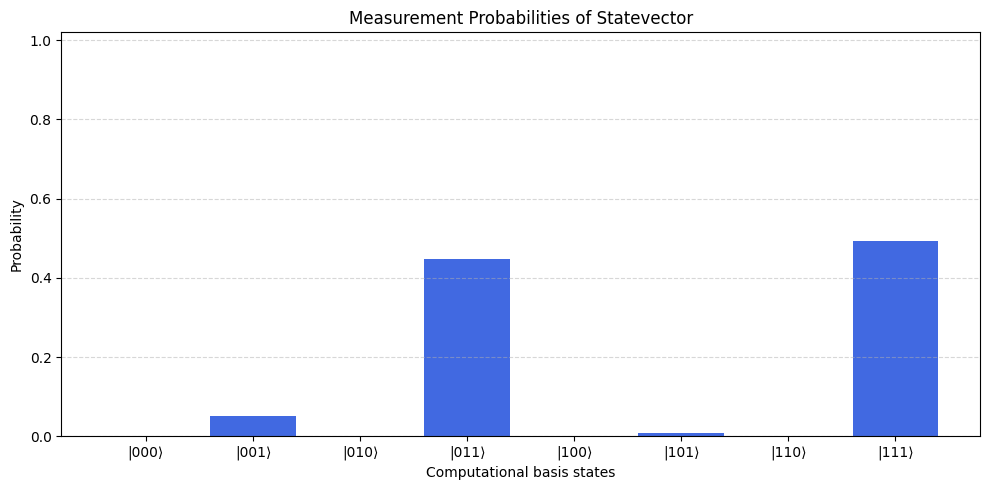

In [261]:
plot_statevector_probabilities(y7n)

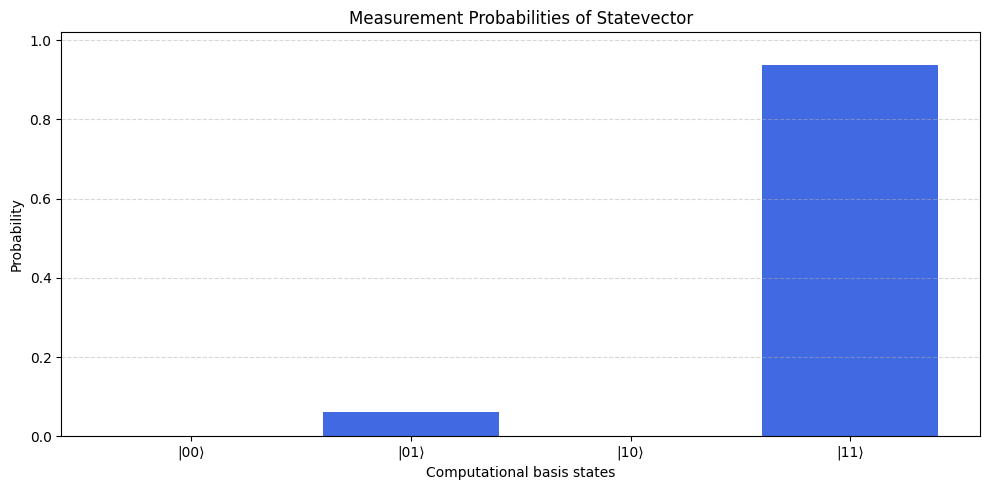

In [251]:
plot_statevector_probabilities(partial_trace(y7n,[2]))

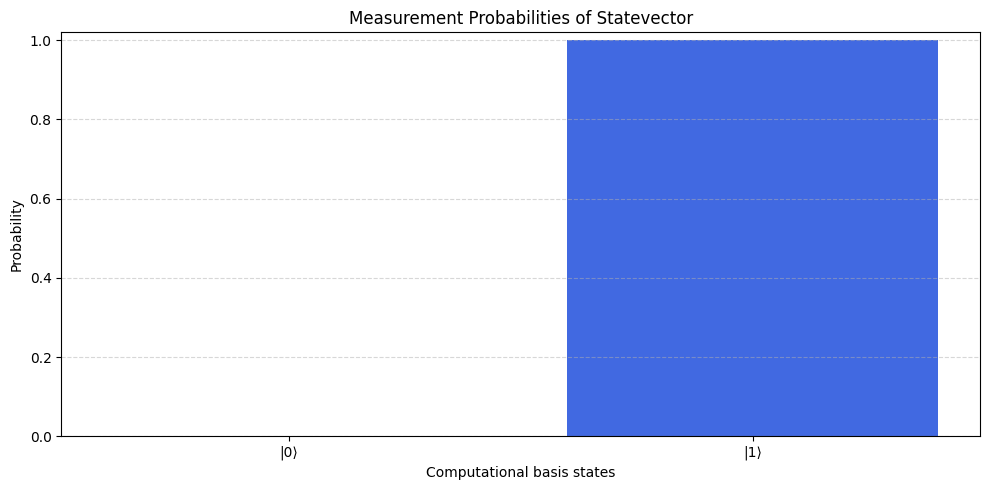

In [235]:
plot_statevector_probabilities(partial_trace(partial_trace(y7n,[2]),[1]))

In [262]:
m_three =  np.array([y0n.data,y1n.data,y2n.data,y3n.data,
           y4n.data,y5n.data,y6n.data,y7n.data])

In [24]:
import gc
gc.collect()

0

In [269]:
U0 = Operator(m_three.transpose())
U = U0.dot(U0.adjoint())

In [270]:
Operator(U).draw("latex")

<IPython.core.display.Latex object>

In [271]:
Operator(np.round(U0.data,)).draw("latex")

<IPython.core.display.Latex object>

In [272]:
Operator(U0).draw("latex")

<IPython.core.display.Latex object>

In [273]:
M0 = U0.data[0:2,0:2]
M1 = U0.data[2:4,2:4]
M2 = U0.data[4:6,4:6]
M3 = U0.data[6:8,6:8]
M0

array([[ 0.45478522-5.35347135e-01j, -0.00245829+4.69293321e-04j],
       [ 0.00143843+2.04809372e-03j, -0.59353228+3.78532699e-01j]])

In [203]:
primera_fila = M0[0,:]

angles=np.angle(primera_fila)

D0 = np.diag([np.exp(1j*angles[i]) for i in range(2)])
D0
# np.exp(np.angle(D0)*1j)


array([[-0.99999881-0.00154378j,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.94731155-0.32031364j]])

In [204]:
M0@np.conjugate(D0)

array([[ 0.98531645+1.56558794e-16j,  0.07113581-3.46944695e-18j],
       [ 0.0631746 +2.90610824e-02j, -0.83923824-5.23463596e-01j]])

In [274]:
import numpy as np

def numpy_to_mathematica(array):
    """Convierte un array NumPy a formato Mathematica"""
    def format_complex(num):
        real = np.real(num)
        imag = np.imag(num)
        if imag == 0:
            return f"{real:.8f}".rstrip('0').rstrip('.') if '.' in f"{real:.8f}" else f"{real:.8f}"
        else:
            real_str = f"{real:.8f}".rstrip('0').rstrip('.') if real != 0 else ""
            imag_str = f"{abs(imag):.8f}".rstrip('0').rstrip('.') if imag != 0 else ""
            operator = "+" if imag > 0 else "-"
            if real == 0:
                return f"{imag:.8f}I".rstrip('0').rstrip('.') if '.' in f"{imag:.8f}" else f"{imag:.8f}I"
            else:
                return f"{real_str}{operator}{imag_str}I"

    rows = []
    for row in array:
        elements = [format_complex(x) for x in row]
        rows.append("{" + ", ".join(elements) + "}")
    
    mathematica_str = "{\n  " + ",\n  ".join(rows) + "\n}"
    return mathematica_str

In [275]:
mathematica_str =  numpy_to_mathematica(m_three.transpose())
print(mathematica_str)

{
  {0.45478522-0.53534714I, -0.00245829+0.00046929I, -0.09274689+0.00711389I, 0.00060961-0.0002664I, 0.47258928+0.47264194I, -0.00622962+0.00075026I, -0.22701208+0.02413114I, 0.0012688-0.00057328I},
  {0.00143843+0.00204809I, -0.59353228+0.3785327I, 0.01534069+0.00974232I, 0.09083494+0.02000136I, 0.00353223+0.00538577I, -0.31097232-0.58941361I, 0.02803391+0.01932674I, 0.2241708+0.0436928I},
  {0.05172045+0.0802094I, 0.015583+0.00928802I, -0.07243039+0.69717058I, -0.00309901-0.00057623I, 0.13443239+0.19646219I, 0.02864084+0.0183694I, 0.6632218+0.05904767I, -0.0062651-0.00100435I},
  {0.0000339+0.00069821I, -0.02651677-0.0916522I, 0.00109185+0.00294791I, 0.27389435-0.64429719I, -0.00004094+0.0014994I, -0.07074462-0.22720665I, 0.00176143+0.00624526I, -0.61840905-0.25322011I},
  {-0.11950885-0.65704425I, 0.00572396+0.00298993I, 0.20789122+0.11658091I, -0.00144879-0.00028595I, -0.68564616+0.13338078I, 0.00264283+0.00167836I, 0.08435449+0.0448009I, -0.00065578-0.0001523I},
  {0.0001965-0.00

In [100]:
def evo_GHZ(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-10,
        rtol=1e-10
    )
    # yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return sol

In [55]:
SV_T = evo_GHZ(X_GHZ)

In [56]:
purity(DensityMatrix(SV_T.y[-1]/np.linalg.norm(SV_T.y[-1])))

np.complex128(0.9999999999999998+1.0909564192504486e-17j)

In [57]:
tangle_GHZ = []

for i in SV_T.y:
    tangle_GHZ.append(three_t(i))

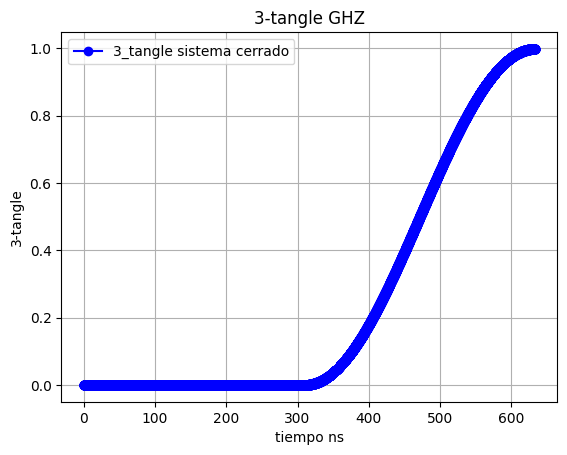

In [58]:
# 2. Crear el gráfico
plt.plot(SV_T.t, tangle_GHZ, marker='o', linestyle='-', color='b', label='3_tangle sistema cerrado')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [59]:
def three_tangle(psi):

    if len(psi.data) != 8:
        raise ValueError("El Statevector debe tener dimensión 8 (3 qubits).")

    # Bipartición A|BC usando pureza reducida
    rho_BC = partial_trace(psi, [0])   # traza sobre A
    C_BC = concurrence(rho_BC)

    # Concurrencias bipartitas correctas
    rho_AB = partial_trace(psi, [2])   # traza sobre C
    C_AB = concurrence(rho_AB)

    rho_AC = partial_trace(psi, [1])   # traza sobre B
    C_AC = concurrence(rho_AC)

    # Three-tangle
    

    return [C_BC,C_AB,C_AC]

In [61]:
def renorma(vector):
    vector = vector/np.linalg.norm(vector)
    return vector 

In [62]:
C_BC = []
C_AB = []
C_AC = []
for k in SV_T.y:
    C_BC.append(three_tangle(renorma(k).data)[0])
    C_AB.append(three_tangle(renorma(k).data)[1])
    C_AC.append(three_tangle(renorma(k).data)[2])

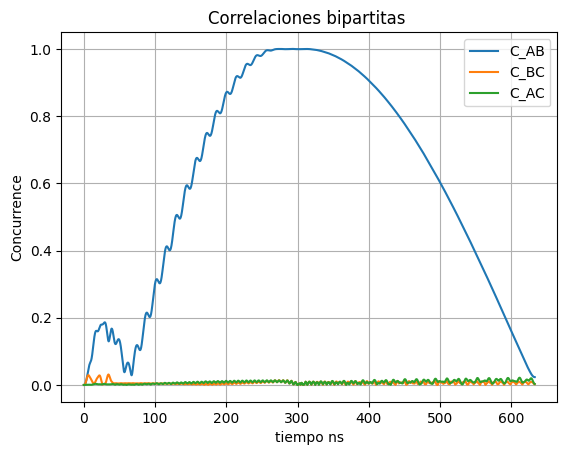

In [63]:
plt.plot(SV_T.t, C_AB,label="C_AB")
plt.plot(SV_T.t,C_BC, label ="C_BC")
plt.plot(SV_T.t,C_AC, label= "C_AC")

# 3. Personalizar (opcional)
plt.title("Correlaciones bipartitas ")
plt.xlabel("tiempo ns")
plt.ylabel("Concurrence")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [64]:
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9

# tiempo de relajación y decoherencia en segundos
T1_7 = propiedades.qubit_property(7,'T1')[0]  # tiempo de relajación
T2_7 = propiedades.qubit_property(7,'T2')[0]  # tiempo de decoherencia
T1_8 = propiedades.qubit_property(8,'T1')[0]  # tiempo de relajación
T2_8 = propiedades.qubit_property(8,'T2')[0]  # tiempo de decoherencia
T1_9 = propiedades.qubit_property(9,'T1')[0]  # tiempo de relajación    
T2_9 = propiedades.qubit_property(9,'T2')[0]  # tiempo de decoherencia  


v7 = w7/(2*np.pi)  # frecuencia en GHz
v8 = w8/(2*np.pi)  # frecuencia en GHz
v9 = w9/(2*np.pi)  # frecuencia en GHz  


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)

# Definir los operadores 
dim = 2
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**3, dtype=complex)

N0 = np.kron(ident,np.kron(ident, N))
N1 = np.kron(ident,np.kron(N, ident))
N2 = np.kron(np.kron(N, ident),ident)

a0 = np.kron(ident,np.kron(ident, a))
a1 = np.kron(ident,np.kron(a, ident))
a2 = np.kron(np.kron(a, ident),ident)


a0dag = np.kron(ident,np.kron(ident, adag))
a1dag = np.kron(ident,np.kron(adag, ident))
a2dag = np.kron(np.kron(adag, ident),ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  +2*np.pi*v8 * N1  + 2*np.pi*v9* N2   + J78*(a0dag @ a1 +  a0 @ a1dag) + J89*(a1dag @ a2 +  a1 @ a2dag)

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)
H_drive9 =  r2 * (a2 + a2dag)
  

# Tiempos T1 y T2 en ns
T1_7 = T1_7*1e9
T2_7 = T2_7*1e9
T1_8 = T1_8*1e9
T2_8 = T2_8*1e9
T1_9 = T1_9*1e9
T2_9 = T2_9*1e9
# gammas de relajación y decoherencia
gamma1_7 = 1/T1_7
gamma2_7 = 1/T2_7 - 1/(2*T1_7)
gamma1_8 = 1/T1_8
gamma2_8 = 1/T2_8 - 1/(2*T1_8)
gamma1_9 = 1/T1_9
gamma2_9 = 1/T2_9 - 1/(2*T1_9)


Z0  = full_ident - 2*N0
Z1  = full_ident - 2*N1
Z2  = full_ident - 2*N2

sm1 = a0
sm2 = a1
sm3 = a2

sz1 = Z0
sz2 = Z1 
sZ3 = Z2

collapse_operators = [np.sqrt(gamma1_7)*a0,
                      np.sqrt(gamma1_8)*a1,
                      np.sqrt(gamma1_9)*a2,
                      np.sqrt(gamma2_7)*Z0,
                      np.sqrt(gamma2_8)*Z1,
                      np.sqrt(gamma2_9)*Z2]

In [99]:
Z0

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
        -1.+0.j]])

In [65]:
print(T1_7, " ", T2_7, "  ", T1_8, "  ", T2_8,  "  ", T1_9, "  ", T2_9)

230522.19090722952   18177.31355943345    394165.10585714877    17282.471331162924    291846.55218305363    56346.802819290395


In [68]:
solver = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [69]:
X_GHZ =  [
    1.91779586e+02, 1.03750354e+03, 1.68736170e+02, 1.45046248e+03,
    4.90394435e-01, -6.91612520e-01, 6.65492967e-01, 1.65200193e-01,
    6.19735822e-01
]

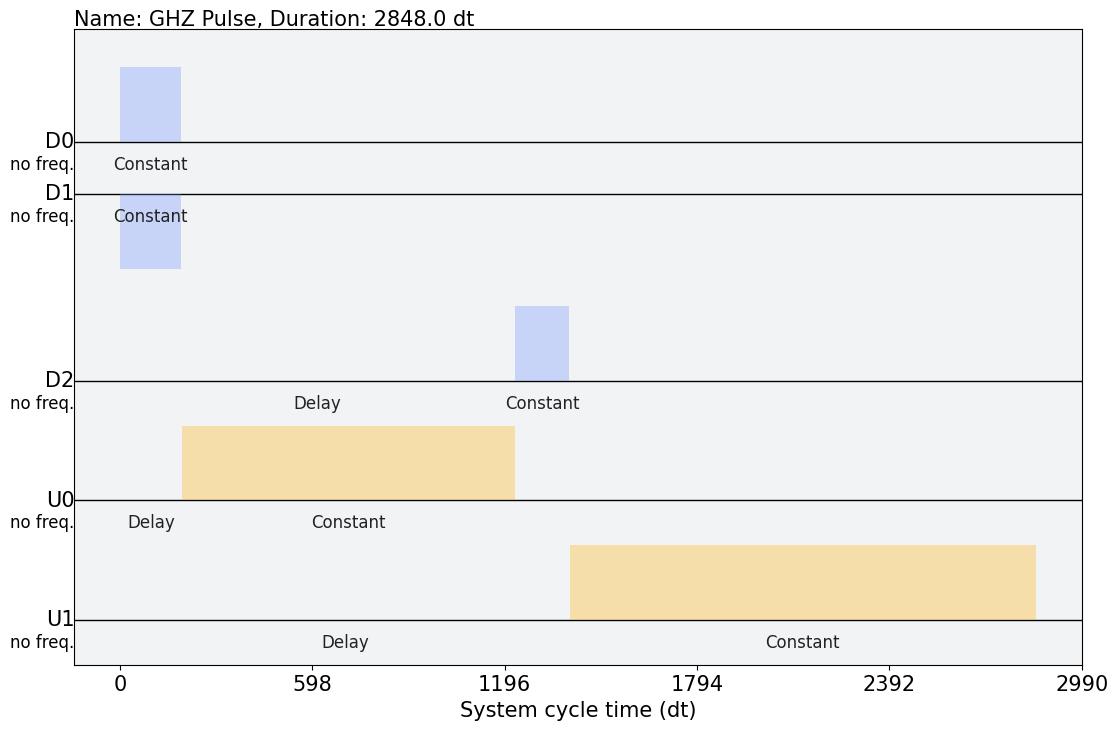

In [30]:
esque_pul(X_GHZ).draw()

In [101]:
def evol_GHZ_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-10,
        rtol=1e-10
    )
    # yf = sol.y[-1]
    
    return sol

In [ ]:
matrix_GHZ = evol_GHZ_lindblab(X_GHZ)

In [106]:
import gc
gc.collect()

0

In [107]:
(matrix_GHZ.y[-1]).is_valid()

True

In [108]:
purity(matrix_GHZ.y[-1])

np.complex128(0.8792344787445684+1.5583198301528723e-19j)

In [109]:
import numpy as np
from qiskit.quantum_info import partial_trace, concurrence

def three_tangle(psi):
    """
    Calcula el three-tangle τ_ABC para un estado puro de tres qubits.
    """

    if len(psi.data) != 8:
        raise ValueError("El Statevector debe tener dimensión 8 (3 qubits).")

    # Bipartición A|BC usando pureza reducida
    rho_A = partial_trace(psi, [1, 2])   # traza sobre B y C
    purity_A = np.trace(rho_A.data @ rho_A.data).real
    C_A_BC = np.sqrt(2 * (1 - purity_A))

    # Concurrencias bipartitas correctas
    rho_AB = partial_trace(psi, [2])   # traza sobre C
    C_AB = concurrence(rho_AB)

    rho_AC = partial_trace(psi, [1])   # traza sobre B
    C_AC = concurrence(rho_AC)

    # Three-tangle
    tau_ABC = C_A_BC**2 - C_AB**2 - C_AC**2
    tau_ABC = np.real_if_close(tau_ABC)

    return float(np.clip(tau_ABC, 0, 1))

In [110]:

def sanitize_density_matrix(rho):
    """
    Corrige una matriz para que sea una matriz densidad física:
    - Hermítica
    - Traza 1
    - Semidefinida positiva
    """
    rho = np.array(rho, dtype=complex)

    # 1) Forzar hermiticidad
    rho = 0.5 * (rho + rho.conj().T)

    # 2) Diagonalizar
    eigvals, eigvecs = np.linalg.eigh(rho)

    # 3) Eliminar negativos pequeños
    eigvals[eigvals < 0] = 0

    # 4) Reconstruir
    rho = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    # 5) Renormalizar traza
    rho = rho / np.trace(rho)

    return DensityMatrix(rho)

In [111]:
three_lindblad_full = []
time_lindblad_full  = []
for k, j in enumerate(matrix_GHZ.y):
    three_lindblad_full.append(three_tangle(sanitize_density_matrix(j.data)))
    time_lindblad_full.append(matrix_GHZ.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

In [114]:
rho_valid = []
for k  in matrix_GHZ.y:
    if k.is_valid() == True:
        rho_valid.append(k)
        
   

In [115]:
three_lindblad_full = []
time_lindblad_full  = []
for k, j in enumerate(rho_valid):
    three_lindblad_full.append(three_tangle(j.data))
    time_lindblad_full.append(matrix_GHZ.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

In [116]:
max(three_lindblad_full)

0.9999855829890418

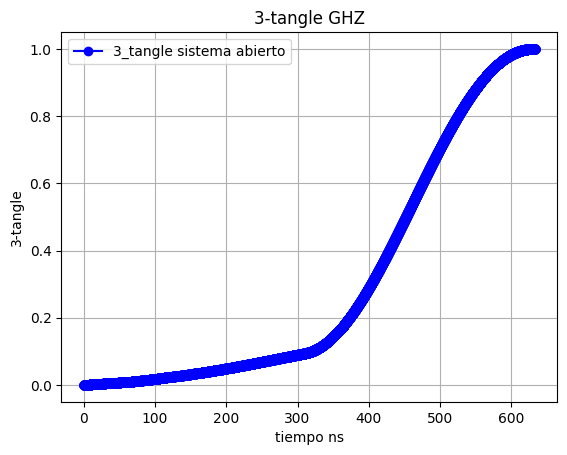

In [117]:
# 2. Crear el gráfico
plt.plot(time_lindblad_full, three_lindblad_full, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [296]:
print(gamma1_7 ,gamma2_7 ,gamma1_8 ,gamma2_8 ,gamma1_9 ,gamma2_9 )

4.337977164213385e-06 5.28446412774625e-05 2.5370079318041274e-06 5.659359114990744e-05 3.426458159330162e-06 1.603400678759603e-05


In [297]:
# solos decaimiento 

collapse_operators_solo_deaimiento = [np.sqrt(gamma1_7)*a0,
                                      np.sqrt(gamma1_8)*a1,
                                      np.sqrt(gamma1_9)*a2,
                                      ]

In [298]:
solver_beta = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators_solo_deaimiento,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [299]:
def evol_GHZ_lindblab_solo_decaimiento(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_beta.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
    return sol

In [300]:
vector_solo_decaimiento  = evol_GHZ_lindblab_solo_decaimiento(X_GHZ)

In [301]:
three_decaimiento = []
time_decaimiento  = []
for k, j in enumerate(vector_solo_decaimiento.y):
    three_decaimiento.append(three_tangle(sanitize_density_matrix(j.data)))
    time_decaimiento.append(vector_solo_decaimiento.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

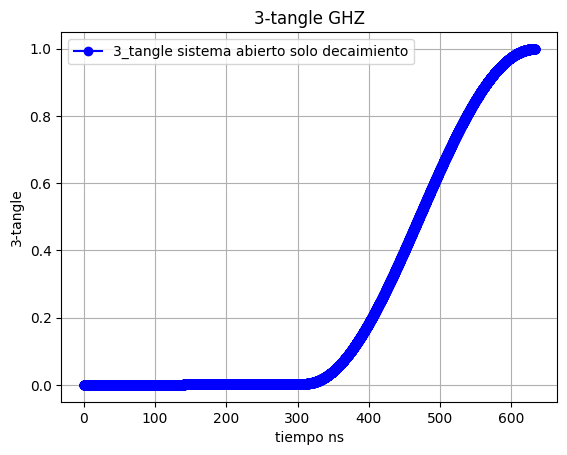

In [302]:
# 2. Crear el gráfico
plt.plot(time_decaimiento, three_decaimiento, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto solo decaimiento')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [303]:
print(gamma1_7 ,gamma2_7 ,gamma1_8 ,gamma2_8 ,gamma1_9 ,gamma2_9 )

4.337977164213385e-06 5.28446412774625e-05 2.5370079318041274e-06 5.659359114990744e-05 3.426458159330162e-06 1.603400678759603e-05


In [304]:
collapse_operators_decaimiento_dos_orden_mas = [np.sqrt(4.337977164213385e-04)*a0,
                                                np.sqrt(2.5370079318041274e-04)*a1,
                                                np.sqrt(3.426458159330162e-04)*a2,
                                                np.sqrt(0)*Z0,
                                                np.sqrt(0)*Z1,
                                                np.sqrt(0)*Z2]

In [305]:
solver_beta = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators_decaimiento_dos_orden_mas,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [306]:
def evol_GHZ_lindblab_dos_orden_mas(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_beta.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
    return sol

In [179]:
vector_dos_orden_mas  = evol_GHZ_lindblab_dos_orden_mas(X_GHZ)

In [180]:
three_dos_orden_mas = []
time_dos_orden_mas = []
for k, j in enumerate(vector_dos_orden_mas.y):
    three_dos_orden_mas.append(three_tangle(sanitize_density_matrix(j.data)))
    time_dos_orden_mas.append(vector_dos_orden_mas.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

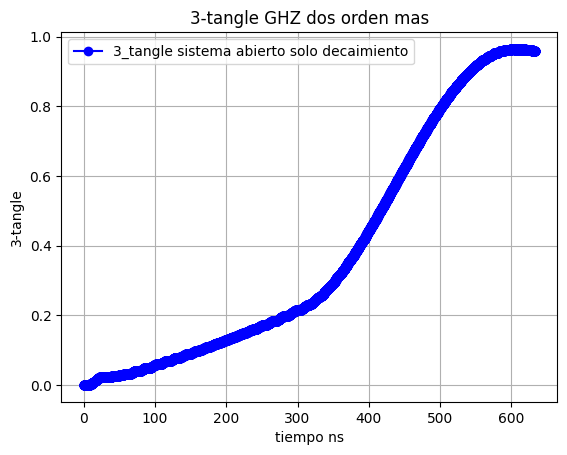

In [183]:
# 2. Crear el gráfico
plt.plot(time_dos_orden_mas, three_dos_orden_mas, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto solo decaimiento')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ dos orden mas")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [203]:
import gc
gc.collect()

0

In [187]:
# con 4 orden mas 

collapse_operators_decaimiento_cuatro_orden_mas = [np.sqrt(4.337977164213385e-02)*a0,
                                                   np.sqrt(2.5370079318041274e-02)*a1,
                                                   np.sqrt(3.426458159330162e-02)*a2,
                                                   np.sqrt(0)*Z0,
                                                   np.sqrt(0)*Z1,
                                                   np.sqrt(0)*Z2]

In [188]:
solver_beta = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators_decaimiento_cuatro_orden_mas,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [189]:
def evol_GHZ_lindblab_cuatro_orden_mas(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_beta.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
        
    return sol
    

In [190]:
vector_cuatro_orden_mas  = evol_GHZ_lindblab_cuatro_orden_mas(X_GHZ)

In [191]:
three_cuatro_orden_mas = []
time_cuatro_orden_mas = []
for k, j in enumerate(vector_cuatro_orden_mas.y):
    three_cuatro_orden_mas.append(three_tangle(sanitize_density_matrix(j.data)))
    time_cuatro_orden_mas.append(vector_cuatro_orden_mas.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

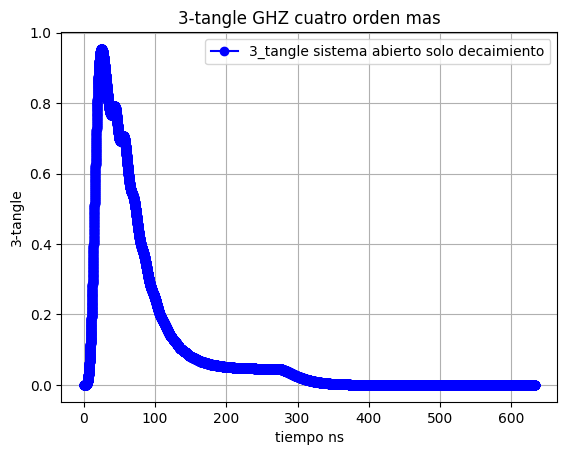

In [192]:
# 2. Crear el gráfico
plt.plot(time_cuatro_orden_mas, three_cuatro_orden_mas, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto solo decaimiento')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ cuatro orden mas")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [193]:
# oreden 6

# con 4 orden mas 

collapse_operators_decaimiento_seis_orden_mas = [np.sqrt(4.337977164213385)*a0,
                                                   np.sqrt(2.5370079318041274)*a1,
                                                   np.sqrt(3.426458159330162)*a2,
                                                   np.sqrt(0)*Z0,
                                                   np.sqrt(0)*Z1,
                                                   np.sqrt(0)*Z2] 

In [194]:
solver_beta = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators_decaimiento_seis_orden_mas,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [195]:
def evol_GHZ_lindblab_seis_orden_mas(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_beta.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
        
    return sol

In [196]:
vector_seis_orden_mas  = evol_GHZ_lindblab_seis_orden_mas(X_GHZ)

In [197]:
three_seis_orden_mas = []
time_seis_orden_mas = []
for k, j in enumerate(vector_seis_orden_mas.y):
    three_seis_orden_mas.append(three_tangle(sanitize_density_matrix(j.data)))
    time_seis_orden_mas.append(vector_seis_orden_mas.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

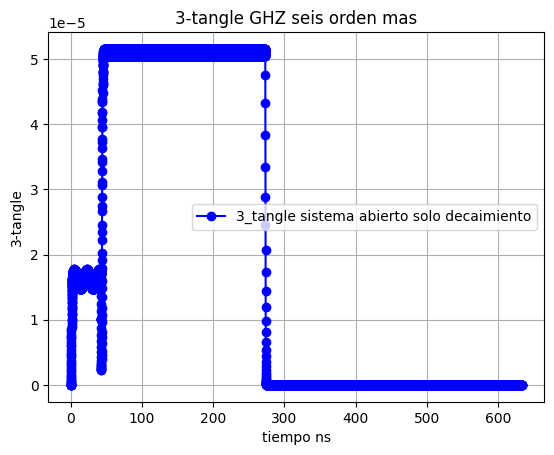

In [198]:
# 2. Crear el gráfico
plt.plot(time_seis_orden_mas, three_seis_orden_mas, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto solo decaimiento')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ seis orden mas")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [109]:
print(w7," ", w8, "  ", w9 )

29.88023890323631   30.23802708662245    29.13898918259225


In [ ]:
# oreden 6



collapse_operators_defase = [            np.sqrt(0)*a0,
                                                   np.sqrt(0)*a1,
                                                   np.sqrt(0)*a2,
                                                   np.sqrt(gamma2_7)*Z0,
                                                   np.sqrt(gamma2_8)*Z1,
                                                   np.sqrt(gamma2_9)*Z2] 

In [200]:
solver_beta = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators_defase,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [201]:
def evol_GHZ_lindblab_defase(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_beta.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
        
    return sol

In [204]:
vector_defase  = evol_GHZ_lindblab_defase(X_GHZ)

In [205]:
three_defase = []
time_defase = []
for k, j in enumerate(vector_defase.y):
    three_defase.append(three_tangle(sanitize_density_matrix(j.data)))
    time_defase.append(vector_defase.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

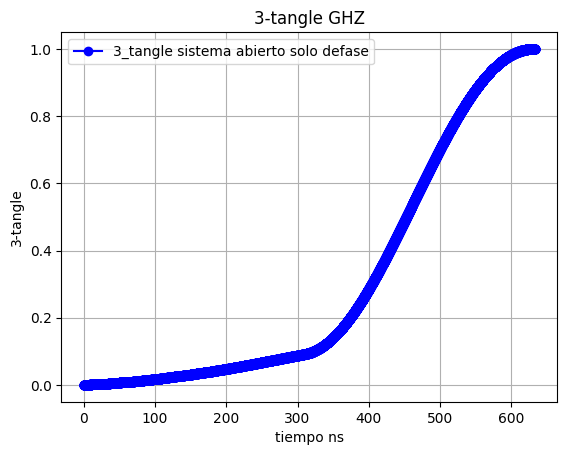

In [206]:
# 2. Crear el gráfico
plt.plot(time_defase, three_defase, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto solo defase')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [207]:
print(gamma1_7 ,gamma2_7 ,gamma1_8 ,gamma2_8 ,gamma1_9 ,gamma2_9 )

4.337977164213385e-06 5.28446412774625e-05 2.5370079318041274e-06 5.659359114990744e-05 3.426458159330162e-06 1.603400678759603e-05


In [208]:
# orden 3

collapse_operators_defase_orden_tres = [            np.sqrt(0)*a0,
                                                   np.sqrt(0)*a1,
                                                   np.sqrt(0)*a2,
                                                   np.sqrt(5.28446412774625e-03)*Z0,
                                                   np.sqrt(5.659359114990744e-03)*Z1,
                                                   np.sqrt(1.603400678759603e-03)*Z2] 

In [209]:
solver_beta = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators_defase_orden_tres,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [211]:
def evol_GHZ_lindblab_defase_orden_tres(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_beta.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
        
    return sol

In [212]:
vector_defase_orden_tres  = evol_GHZ_lindblab_defase_orden_tres(X_GHZ)

In [213]:
three_defase_orden_tres = []
time_defase_orden_tres = []
for k, j in enumerate(vector_defase_orden_tres.y):
    three_defase_orden_tres.append(three_tangle(sanitize_density_matrix(j.data)))
    time_defase_orden_tres.append(vector_defase_orden_tres.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

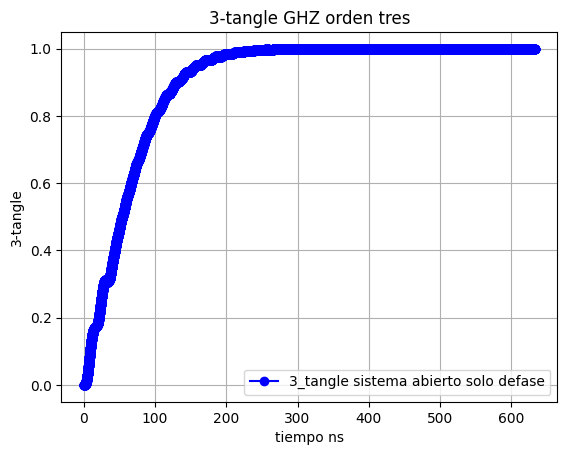

In [214]:
# 2. Crear el gráfico
plt.plot(time_defase_orden_tres, three_defase_orden_tres, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto solo defase')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ orden tres")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

In [216]:
# cero orden

collapse_operators_defase_orden_cero = [            np.sqrt(0)*a0,
                                                   np.sqrt(0)*a1,
                                                   np.sqrt(0)*a2,
                                                   np.sqrt(5.28446412774625)*Z0,
                                                   np.sqrt(5.659359114990744)*Z1,
                                                   np.sqrt(1.603400678759603)*Z2] 

In [217]:
solver_beta = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                static_dissipators = collapse_operators_defase_orden_cero,
                dissipator_channels= None,
                hamiltonian_channels= ["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library='jax'
                )





rho_0 = DensityMatrix.from_label('000')

In [218]:
def evol_GHZ_lindblab_defase_orden_cero(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_beta.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    # yf = sol.y[-1]
    
        
    return sol

In [219]:
vector_defase_orden_cero  = evol_GHZ_lindblab_defase_orden_cero(X_GHZ)

In [220]:
three_defase_orden_cero = []
time_defase_orden_cero = []
for k, j in enumerate(vector_defase_orden_cero.y):
    three_defase_orden_cero.append(three_tangle(sanitize_density_matrix(j.data)))
    time_defase_orden_cero.append(vector_defase_orden_cero.t[k])
    # print(three_tangle(sanitize_density_matrix(j.data)), " ", k)

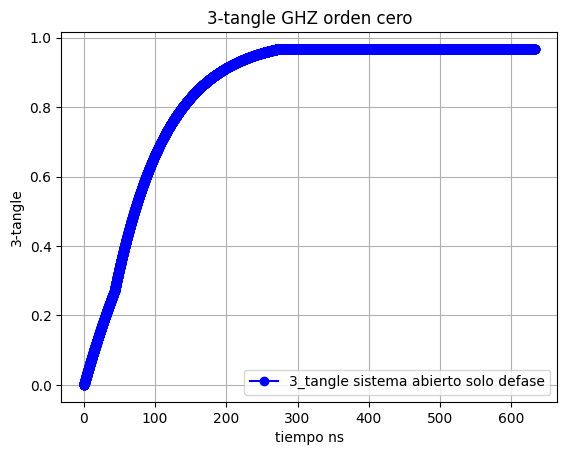

In [221]:
# 2. Crear el gráfico
plt.plot(time_defase_orden_cero, three_defase_orden_cero, marker='o', linestyle='-', color='b', label='3_tangle sistema abierto solo defase')

# 3. Personalizar (opcional)
plt.title("3-tangle GHZ orden cero")
plt.xlabel("tiempo ns")
plt.ylabel("3-tangle")
plt.legend()
plt.grid(True)

# 4. Mostrar el gráfico
plt.show()

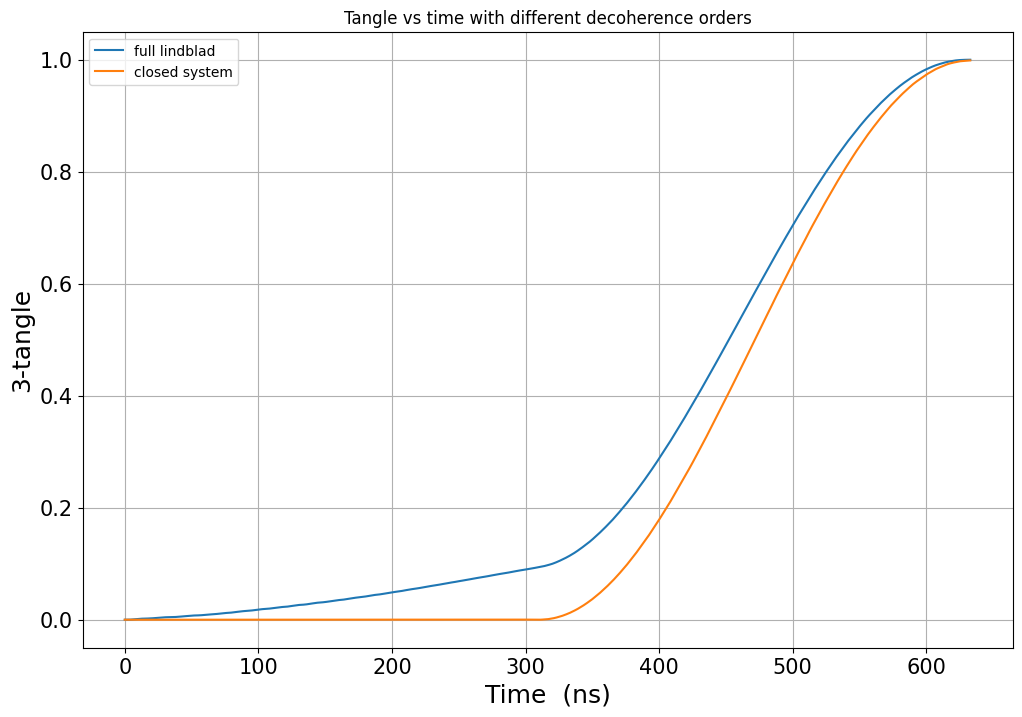

: 

In [ ]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,8))
# plt.plot(time_defase_orden_cero,three_defase_orden_cero, label = 'only dephasing order e0')
# plt.plot(time_defase_orden_tres,three_defase_orden_tres, label = 'only dephasing order e-3')
# plt.plot(time_defase,three_defase, label = 'only dephasing order e-5')
# plt.plot(time_seis_orden_mas ,three_seis_orden_mas , label = 'only relaxation ornder 0')
# plt.plot(time_cuatro_orden_mas, three_cuatro_orden_mas, label='only relaxation order e-2')
# plt.plot(time_dos_orden_mas, three_dos_orden_mas,  label='only relaxation order e-4')
plt.plot(time_lindblad_full, three_lindblad_full,  label='full lindblad')
plt.plot(SV_T.t, tangle_GHZ,label='closed system')
plt.title("Tangle vs time with different decoherence orders")
plt.xlabel('Time  (ns)', fontsize=18)
plt.ylabel('3-tangle', fontsize= 18 )
plt.xticks(fontsize=15) # Aumenta tamaño números eje x
plt.yticks(fontsize=15) # Aumenta tamaño números eje y
plt.legend()
plt.grid(True)
plt.show()

Distancia de Bures

In [26]:
GHZ = Statevector([1/np.sqrt(2), 0, 0, 0, 0, 0, 0, 1/np.sqrt(2)])
GHZ.draw("latex")

<IPython.core.display.Latex object>

In [27]:
from qiskit.circuit import QuantumCircuit, Parameter
import math
angles =  [random.uniform(0, math.pi), random.uniform(0, math.pi * 2),random.uniform(0, math.pi * 2),
           random.uniform(0, math.pi), random.uniform(0, math.pi * 2),random.uniform(0, math.pi * 2),     
           random.uniform(0, math.pi), random.uniform(0, math.pi * 2),random.uniform(0, math.pi * 2)] 

simu = QuantumCircuit(3)
simu.initialize(objective_12(X_GHZ).data,simu.qubits)
simu.u(angles[0], angles[1], angles[2], 0)
simu.u(angles[3], angles[4], angles[5], 1)
simu.u(angles[6], angles[7], angles[8], 2)

np.abs(Statevector(simu).inner(GHZ))

np.float64(0.7261518400594312)

In [52]:
from qiskit.circuit import QuantumCircuit, Parameter
def DB(angulos):
    [k1, k2, k3, k4, k5, k6, k7, k8, k9] = angulos
    simuc = QuantumCircuit(3)
    simuc.initialize(objective_12(X_GHZ))
    simuc.u(k1, k2, k3, 0)
    simuc.u(k4, k5, k6, 1)
    simuc.u(k7, k8, k9, 2)
    

    inner = np.abs(Statevector(simuc).inner(GHZ))
    
    inner = np.clip(inner, 0, 1) 
    
    bure = 2*(1 - inner)

    return bure

In [56]:
from qiskit.circuit import QuantumCircuit, Parameter
def DB(angulos):
    [k1, k2, k3, k4, k5, k6, k7, k8, k9] = angulos
    simuc = QuantumCircuit(3)
    simuc.initialize(objective_12(X_GHZ))
    simuc.u(k1, k2, k3, 0)
    simuc.u(k4, k5, k6, 1)
    simuc.u(k7, k8, k9, 2)
    

    inner = np.abs(Statevector(simuc).inner(GHZ))
    
    inner = np.clip(inner, 0, 1) 
    
    bure = np.sqrt(2 * (1 - inner))

    return bure

In [57]:
DB([2.722e+00,  5.544e+00,  5.382e+00,  2.780e+00,1.527e+00,  
 3.786e+00,  2.752e+00,  4.501e+00,2.240e+00])

np.float64(0.04344512487348286)

In [58]:
DB([ 2.696e+00,  5.365e+00,  5.258e+00,  2.790e+00,  1.586e+00,
    3.698e+00,  2.771e+00,  4.296e+00,  2.109e+00])

np.float64(0.01316828886583581)

In [55]:
np.sqrt(0.0018874788752725191)

np.float64(0.04344512487348286)

In [29]:
k1 = random.uniform(0, math.pi)
k2 = random.uniform(0, math.pi * 2)
k3 = random.uniform(0, math.pi * 2)
k4 = random.uniform(0, math.pi)
k5 = random.uniform(0, math.pi * 2)
k6 = random.uniform(0, math.pi * 2)
k7 = random.uniform(0, math.pi)
k8 = random.uniform(0, math.pi * 2)
k9 = random.uniform(0, math.pi * 2)

In [30]:
DB([k1, k2, k3, k4, k5, k6, k7, k8, k9])

np.float64(0.5059966557696501)

In [59]:
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

def callback(xk):
    costo = DB(xk)
    print(f"Cost: {costo:.6f} | x: {xk}")

# ---------- PUNTO INICIAL ----------

a_1 = random.uniform(0, math.pi)
a_2 = random.uniform(0, math.pi * 2)
a_3 = random.uniform(0, math.pi * 2)
a_4 = random.uniform(0, math.pi)
a_5 = random.uniform(0, math.pi * 2)
a_6 = random.uniform(0, math.pi * 2)
a_7 = random.uniform(0, math.pi)
a_8 = random.uniform(0, math.pi * 2)
a_9 = random.uniform(0, math.pi * 2)

x0 = [ 2.696e+00,  5.365e+00,  5.258e+00,  2.790e+00,  1.586e+00,
    3.698e+00,  2.771e+00,  4.296e+00,  2.109e+00]
#--------------------------------------
bounds = [(0, math.pi),(0, math.pi * 2),(0, math.pi * 2),
      (0, math.pi),(0, math.pi * 2),(0, math.pi * 2),
      (0, math.pi),(0, math.pi * 2),(0, math.pi * 2),
]

# ---------- OPTIMIZACIÓN ----------
result = minimize(
    fun=DB,
    x0=x0,
    method='Nelder-Mead',
    callback=callback,
    options={
        'disp': True,
        'maxiter': 100,     # puedes aumentarlo más si quieres
        'fatol': 1e-10       # criterio de convergencia más estricto
    }
)

print("Resultado final:")
print(result)

Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.013168 | x: [2.696 5.365 5.258 2.79  1.586 3.698 2.771 4.296 2.109]
Cost: 0.0131

C:\Users\PC\AppData\Local\Temp\ipykernel_16644\2481824106.py:29: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(


Resultado final:
       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.011597773777478402
             x: [ 2.698e+00  5.355e+00  5.241e+00  2.789e+00  1.601e+00
                  3.713e+00  2.766e+00  4.306e+00  2.126e+00]
           nit: 100
          nfev: 173
 final_simplex: (array([[ 2.698e+00,  5.355e+00, ...,  4.306e+00,
                         2.126e+00],
                       [ 2.699e+00,  5.350e+00, ...,  4.308e+00,
                         2.125e+00],
                       ...,
                       [ 2.698e+00,  5.354e+00, ...,  4.308e+00,
                         2.126e+00],
                       [ 2.699e+00,  5.352e+00, ...,  4.304e+00,
                         2.123e+00]], shape=(10, 9)), array([ 1.160e-02,  1.160e-02,  1.163e-02,  1.163e-02,
                        1.166e-02,  1.167e-02,  1.167e-02,  1.168e-02,
                        1.169e-02,  1.169e-02]))


In [ ]:
[0.44279227, 4.46645701, 2.09779989, 0.35364311, 0.4784834, 0.57891449, 0., 0.6759182, 0.94504804]

[ 2.696e+00  5.365e+00  5.258e+00  2.790e+00  1.586e+00
                  3.698e+00  2.771e+00  4.296e+00  2.109e+00]

In [46]:
# ---------- WRAPPER PARA VER CADA EVALUACIÓN ----------
eval_counter = {"count": 0}  # diccionario mutable para llevar la cuenta

def DB_wrapper(angles):
    eval_counter["count"] += 1
    cost = DB(angles)
    print(f"[Eval {eval_counter['count']}] Costo: {cost:.6e}")
    return cost

# ---------- BOUNDS (todo SU(2)) ----------


bounds = [
    (0, 2.722e+00), (0, 5.544e+00), (0,  5.382e+00),  # qubit 0
    (0, 2.780e+00), (0, 1.527e+00), (0, 3.786e+00),  # qubit 1
    (0, 2.752e+00), (0, 4.501e+00), (0, 2.240e+00)   # qubit 2
]

# ---------- CALLBACK PARA VER CADA GENERACIÓN ----------
def callback_fn(xk, convergence=None):
    cost = DB(xk)
    print(f"--> [Generación completada] Mejor costo: {cost:.6e} | Parámetros: {np.round(xk, 4)}")

# ---------- OPTIMIZACIÓN GLOBAL ----------
result = differential_evolution(
    DB_wrapper,        # usamos el wrapper aquí
    bounds=bounds,
    maxiter=10,        # baja el número si quieres probar rápido
    popsize=10,
    tol=1e-8,
    mutation=(0.5, 1),
    recombination=0.7,
    disp=False,
    polish=True,
    workers=1,         # secuencial para ver cada evaluación en orden
    callback=callback_fn
)

print("\nResultado final:")
print(result)
print("\nMejor vector de parámetros encontrado:")
print(result.x)
print(f"Mejor costo: {result.fun:.6e}")

[Eval 1] Costo: 1.245232e+00
[Eval 2] Costo: 1.125253e+00
[Eval 3] Costo: 7.006389e-01
[Eval 4] Costo: 1.318508e+00
[Eval 5] Costo: 1.301750e+00
[Eval 6] Costo: 1.319519e+00
[Eval 7] Costo: 1.338192e+00
[Eval 8] Costo: 1.332214e+00
[Eval 9] Costo: 1.006817e+00
[Eval 10] Costo: 1.144569e+00
[Eval 11] Costo: 1.270672e+00
[Eval 12] Costo: 1.066844e+00
[Eval 13] Costo: 1.213187e+00
[Eval 14] Costo: 1.248881e+00
[Eval 15] Costo: 1.221801e+00
[Eval 16] Costo: 9.867478e-01
[Eval 17] Costo: 1.216127e+00
[Eval 18] Costo: 9.919475e-01
[Eval 19] Costo: 1.270396e+00
[Eval 20] Costo: 7.973581e-01
[Eval 21] Costo: 8.203936e-01
[Eval 22] Costo: 1.359434e+00
[Eval 23] Costo: 1.335690e+00
[Eval 24] Costo: 1.045502e+00
[Eval 25] Costo: 1.170998e+00
[Eval 26] Costo: 1.088453e+00
[Eval 27] Costo: 9.299456e-01
[Eval 28] Costo: 1.328004e+00
[Eval 29] Costo: 9.669488e-01
[Eval 30] Costo: 1.274347e+00
[Eval 31] Costo: 1.241258e+00
[Eval 32] Costo: 1.361133e+00
[Eval 33] Costo: 1.381302e+00
[Eval 34] Costo: 1.